# Integration & Probability Bridge

积分是概率统计的数学地基：概率 = 密度函数的积分，期望 = 加权的积分。本课从黎曼和出发，打通积分、微积分基本定理、概率密度、期望、正态分布与蒙特卡洛——为下一个模块（概率统计）铺路。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 定积分：黎曼和的极限


把区间 $[a,b]$ 切成 $n$ 段，每段取左端点函数值作高，矩形面积求和：

$$\int_a^b f(x)\,dx = \lim_{n\to\infty} \sum_{i=0}^{n-1} f(x_i)\,\Delta x$$

"曲线下的面积"——用矩形逼近，段数越多越准。代码验证 $\int_0^1 x^2\,dx = 1/3$：


n =     2  黎曼和 = 0.125000  误差 = 2.08e-01
n =     4  黎曼和 = 0.218750  误差 = 1.15e-01
n =     8  黎曼和 = 0.273438  误差 = 5.99e-02
n =    16  黎曼和 = 0.302734  误差 = 3.06e-02
n =  1000  黎曼和 = 0.332834  误差 = 5.00e-04


Text(0, 0.5, 'y')

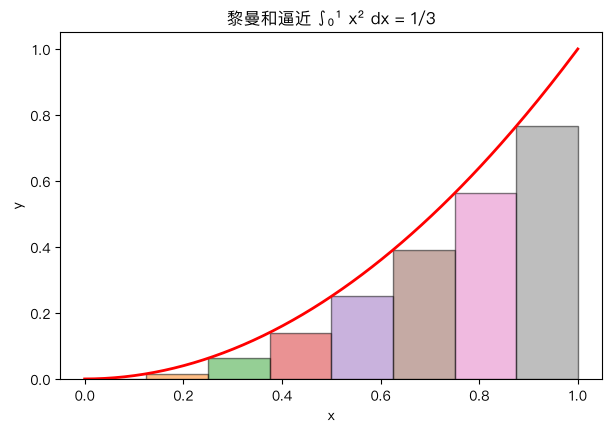

In [2]:
f = lambda x: x**2
a, b = 0.0, 1.0

for n in [2, 4, 8, 16, 1000]:
    xs = np.linspace(a, b, n+1)[:-1]
    dx = (b - a) / n
    riemann = np.sum(f(xs)) * dx
    print(f"n = {n:5d}  黎曼和 = {riemann:.6f}  误差 = {abs(riemann - 1/3):.2e}")

# 可视化 n=8
n = 8
xs = np.linspace(a, b, n+1)
plt.figure(figsize=(7, 4.5))
for i in range(n):
    plt.bar(xs[i], f(xs[i]), width=(b-a)/n, align='edge', alpha=0.5, edgecolor='black')
xx = np.linspace(a, b, 200)
plt.plot(xx, f(xx), 'r-', linewidth=2)
plt.title('黎曼和逼近 ∫₀¹ x² dx = 1/3'); plt.xlabel('x'); plt.ylabel('y')


## 2. 微积分基本定理


**第一基本定理**：$\dfrac{d}{dx}\int_a^x f(t)\,dt = f(x)$——求导与积分互逆。

**第二基本定理（牛顿-莱布尼茨）**：若 $F' = f$，则

$$\int_a^b f(x)\,dx = F(b) - F(a)$$

用数值积分验证：$\int_a^b f'(x)\,dx = f(b) - f(a)$。


In [3]:
def riemann_midpoint(g, a, b, n=100000):
    """中点黎曼和：误差 O(1/n²)，比左端点法高一阶"""
    xs = np.linspace(a, b, n+1)
    mids = (xs[:-1] + xs[1:]) / 2
    return np.sum(g(mids)) * (b - a) / n

f  = lambda x: np.exp(x) * np.sin(x)
df = lambda x: np.exp(x) * (np.sin(x) + np.cos(x))   # 解析导数
a, b = 0.0, 1.5

lhs = riemann_midpoint(df, a, b)     # ∫ f'(x) dx
rhs = f(b) - f(a)                    # f(b) - f(a)
print(f"∫ f'(x)dx = {lhs:.10f}")
print(f"f(b)-f(a)  = {rhs:.10f}")
print(f"误差 = {abs(lhs - rhs):.2e}")


∫ f'(x)dx = 4.4704623792
f(b)-f(a)  = 4.4704623792
误差 = 1.28e-11


## 3. 概率密度与期望：积分是桥梁


连续随机变量 $X$ 的密度函数 $p(x)$ 满足 $\int_{-\infty}^{\infty} p(x)\,dx = 1$，且：

$$P(a \le X \le b) = \int_a^b p(x)\,dx, \qquad \mathbb{E}[X] = \int_{-\infty}^{\infty} x\,p(x)\,dx$$

期望就是"以概率密度为权重的平均"。代码用数值积分验证均匀分布与正态分布的期望：


In [4]:
def riemann_integral(g, a, b, n=100000):
    xs = np.linspace(a, b, n+1)[:-1]
    return np.sum(g(xs)) * (b - a) / n

# 均匀分布 U(0,1)：密度 p(x) = 1，E[X] = ∫₀¹ x·1 dx = 1/2
E_unif = riemann_integral(lambda x: x * 1.0, 0, 1)
print(f"U(0,1) 的 E[X] = {E_unif:.6f}（解析 0.5）")

# 标准正态 N(0,1)：φ(x) = e^{-x²/2}/√(2π)，E[X] = ∫ x·φ(x) dx = 0（奇函数）
phi = lambda x: np.exp(-x**2/2) / np.sqrt(2*np.pi)
E_norm = riemann_integral(lambda x: x * phi(x), -8, 8, n=200000)
print(f"N(0,1) 的 E[X] = {E_norm:.6f}（解析 0）")

# 密度积分为 1
total = riemann_integral(phi, -8, 8, n=200000)
print(f"N(0,1) 密度积分 = {total:.6f}（应为 1）")


U(0,1) 的 E[X] = 0.499995（解析 0.5）
N(0,1) 的 E[X] = 0.000000（解析 0）
N(0,1) 密度积分 = 1.000000（应为 1）


## 4. 正态分布：标准化与 68-95-99.7


正态 $X \sim N(\mu, \sigma^2)$ 的密度：

$$p(x) = \frac{1}{\sqrt{2\pi}\sigma}\,e^{-(x-\mu)^2/(2\sigma^2)}$$

标准化 $Z = (X-\mu)/\sigma \sim N(0,1)$。累积分布函数 $\Phi(z) = P(Z \le z)$ 与误差函数 $\mathrm{erf}$ 的关系：

$$\Phi(z) = \frac{1}{2}\Big(1 + \mathrm{erf}\big(z/\sqrt{2}\big)\Big)$$

用 $\Phi$ 验证 68-95-99.7 法则：


In [5]:
def normal_cdf(z):
    return 0.5 * (1 + math.erf(z / np.sqrt(2)))

for k in [1, 2, 3]:
    p = normal_cdf(k) - normal_cdf(-k)
    print(f"P(|X| ≤ {k}σ) = {p:.6f}")


P(|X| ≤ 1σ) = 0.682689
P(|X| ≤ 2σ) = 0.954500
P(|X| ≤ 3σ) = 0.997300


## 5. 期望的线性性质与方差


$$\mathbb{E}[aX + b] = a\,\mathbb{E}[X] + b, \qquad \mathbb{E}[X+Y] = \mathbb{E}[X] + \mathbb{E}[Y]$$

$$\mathrm{Var}[X] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2, \qquad X \perp Y \Rightarrow \mathrm{Var}[X+Y] = \mathrm{Var}[X] + \mathrm{Var}[Y]$$

用蒙特卡洛（大量采样求平均）验证——这本身就是在用"大数定律近似积分"：


In [6]:
rng = np.random.default_rng(7)
X = rng.standard_normal(200000)
Y = rng.standard_normal(200000)

print(f"E[2X+3] ≈ {np.mean(2*X + 3):.4f}（解析 3）")
print(f"Var[X]  ≈ {np.mean(X**2) - np.mean(X)**2:.4f}（解析 1）")
print(f"Var[X+Y]≈ {np.var(X+Y):.4f}（独立，解析 2）")


E[2X+3] ≈ 3.0019（解析 3）
Var[X]  ≈ 0.9981（解析 1）
Var[X+Y]≈ 1.9940（独立，解析 2）


## 6. 蒙特卡洛积分


**大数定律**：样本均值收敛到期望，$\tfrac1n\sum_i g(X_i) \to \mathbb{E}[g(X)]$。于是积分可以用采样估计：

$$\int g(x)\,p(x)\,dx \approx \frac{1}{n}\sum_{i=1}^n g(X_i), \qquad X_i \sim p$$

误差 $\propto 1/\sqrt{n}$：想精度 ×10，样本要 ×100。经典例子：随机撒点估 $\pi$。


In [7]:
rng = np.random.default_rng(42)
for n in [100, 1000, 10000, 100000]:
    pts = rng.random((n, 2))
    inside = (pts**2).sum(axis=1) <= 1.0
    pi_hat = 4 * inside.mean()
    print(f"n = {n:7d}  π̂ = {pi_hat:.5f}  误差 = {abs(pi_hat - np.pi):.2e}")


n =     100  π̂ = 3.04000  误差 = 1.02e-01
n =    1000  π̂ = 3.11600  误差 = 2.56e-02
n =   10000  π̂ = 3.15440  误差 = 1.28e-02
n =  100000  π̂ = 3.14716  误差 = 5.57e-03


Text(0.5, 1.0, '蒙特卡洛积分误差 ∝ 1/√n：精度×10 需要样本×100')

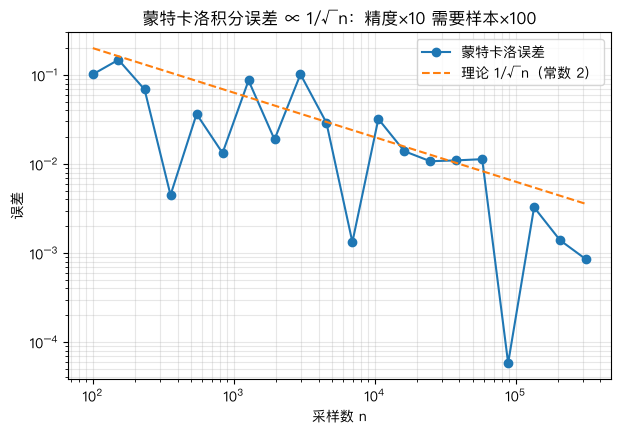

In [8]:
# 误差随 n 按 1/√n 缩小
rng = np.random.default_rng(1)
ns = np.logspace(2, 5.5, 20).astype(int)
errs = []
for n in ns:
    pts = rng.random((n, 2))
    inside = (pts**2).sum(axis=1) <= 1.0
    errs.append(abs(4*inside.mean() - np.pi))

plt.figure(figsize=(7, 4.5))
plt.loglog(ns, errs, 'o-', label='蒙特卡洛误差')
plt.loglog(ns, 2/np.sqrt(ns), '--', label='理论 1/√n（常数 2）')
plt.xlabel('采样数 n'); plt.ylabel('误差')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.title('蒙特卡洛积分误差 ∝ 1/√n：精度×10 需要样本×100')


## 7. 深度学习中的积分视角（预告）


- **泛化损失是期望**：$L_{\text{true}} = \int \ell(x, y)\,dP(x,y)$，训练集上的平均损失只是它的蒙特卡洛估计
- **mini-batch = 小样本蒙特卡洛**：batch 梯度是期望梯度的无偏估计（呼应 06 课 SGD）
- **交叉熵 = 期望负对数似然**：$\mathbb{E}_P[-\log q]$，是概率统计模块的核心概念

积分到此完成使命：它把"概率"和"期望"变成可计算的量，下一模块《概率统计》将系统展开。


## 课后练习


1. **黎曼和**：用左端点矩形逼近 $\int_0^{\pi} \sin x\,dx = 2$，画出 $n=16$ 的矩形图。
2. **分部积分**：求 $\int_0^{\infty} x e^{-x}\,dx$（提示：$\int u\,dv = uv - \int v\,du$），数值验证。
3. **蒙特卡洛**：估计 $\int_0^1 e^{-x^2}\,dx$（提示：用 $U(0,1)$ 采样），画出误差随 $n$ 的变化。
4. **68-95-99.7**：不用 `math.erf`，改用数值积分 $\int_{-k}^{k} \phi(x)\,dx$ 验证三档概率。
5. **思考**：为什么 $\mathbb{E}[X] = \int x\,p(x)\,dx$ 是"概率加权平均"？（对照离散情形 $\sum x_i P(x_i)$）
